# Reproducible EDA Notebook (EDA-1 to EDA-5)

This notebook runs exploratory data analysis using the already prepared processed files.

- `TRAIN_DATA_PATH` points to the train split with engineered features.
- `TEST_DATA_PATH` points to the raw test split (no engineered features).
- Paths are relative to the repository root.
- The train/test split is already done and is **not** recreated here.
- `TARGET_COLUMN` is set explicitly in the config cell.

In [1]:
# Core imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid", context="notebook")

# -------------------------
# User-configurable settings
# -------------------------
# Paths are relative to this notebook directory: 00_analysis/05_EDA/
TRAIN_DATA_PATH = "../../01_data/01_processed/train_set_with_features.csv"
TEST_DATA_PATH = "../../01_data/01_processed/test_raw.csv"
TARGET_COLUMN = "toxic"
PROBLEM_TYPE = "classification"

In [2]:
# Load processed train split with engineered features
# and raw test split for representativeness checks.
df = pd.read_csv(TRAIN_DATA_PATH)
df_test = pd.read_csv(TEST_DATA_PATH)

print(f"Loaded train file: {TRAIN_DATA_PATH}")
print(f"Train shape: {df.shape}")
print(f"Loaded test file:  {TEST_DATA_PATH}")
print(f"Test shape:  {df_test.shape}")
display(df.head())

Loaded train file: ../../01_data/01_processed/train_set_with_features.csv
Train shape: (127656, 40)
Loaded test file:  ../../01_data/01_processed/test_raw.csv
Test shape:  (31915, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,vader_compound,vader_neg,vader_pos,vader_is_negative,vader_intensity,vader_pos_minus_neg,has_second_person,second_person_count,second_person_density,profanity_count,obfuscated_profanity_count,slang_count,char_count,word_count,exclamation_count,uppercase_ratio,unique_word_ratio,elongated_token_count,consecutive_punct_count,url_count,ip_count,has_url_or_ip,negation_count,sentence_count,avg_sentence_length,identity_mention_count,identity_race,identity_gender,identity_sexuality,identity_religion,identity_disability,identity_nationality
0,6ff62abb9f08ee3d,And more unfounded personal attacks by here a...,0,0,0,0,0,0,-0.0935,0.187,0.179,1.0,0.0935,-0.008,0.0,0.0,0.000000,0,0,0,184,34,0,0.0,0.941176,0,0,0,0,0,0,4,8.500000,0,0,0,0,0,0,0
1,c438cd4e8073254a,Gilmore Girls \r\n\r\nI'm trying to figure out...,0,0,0,0,0,0,0.3975,0.018,0.043,0.0,0.3975,0.025,1.0,2.0,0.030303,0,0,0,323,66,0,0.0,0.681818,0,0,0,0,0,2,5,13.200000,0,0,0,0,0,0,0
2,2d7e5045431a4c70,What is the need of tagging..when we can impro...,0,0,0,0,0,0,-0.4927,0.226,0.107,1.0,0.4927,-0.119,0.0,0.0,0.000000,0,0,0,123,21,0,0.0,0.904762,0,2,0,0,0,0,3,7.666667,0,0,0,0,0,0,0
3,ddb267b1a581c366,"03:27, Jun 23, 2005 (UTC)",0,0,0,0,0,0,0.0000,0.000,0.000,0.0,0.0000,0.000,0.0,0.0,0.000000,0,0,0,25,5,0,0.2,1.000000,0,0,0,0,0,0,1,5.000000,0,0,0,0,0,0,0
4,53252a7f4f4bf87d,Inconsistencies \r\n\r\nThis article seems to ...,0,0,0,0,0,0,0.3182,0.000,0.081,0.0,0.3182,0.081,0.0,0.0,0.000000,0,0,0,146,27,0,0.0,0.888889,0,0,0,0,0,2,3,9.000000,0,0,0,0,0,0,0


## EDA-1: Initial Report

This section covers the dataset overview, missing values, duplicates, and data-type composition.

<class 'pandas.DataFrame'>
RangeIndex: 127656 entries, 0 to 127655
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   id                          127656 non-null  str    
 1   comment_text                127656 non-null  str    
 2   toxic                       127656 non-null  int64  
 3   severe_toxic                127656 non-null  int64  
 4   obscene                     127656 non-null  int64  
 5   threat                      127656 non-null  int64  
 6   insult                      127656 non-null  int64  
 7   identity_hate               127656 non-null  int64  
 8   vader_compound              127656 non-null  float64
 9   vader_neg                   127656 non-null  float64
 10  vader_pos                   127656 non-null  float64
 11  vader_is_negative           127656 non-null  float64
 12  vader_intensity             127656 non-null  float64
 13  vader_pos_minus_neg      

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,127656,127656,6ff62abb9f08ee3d,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
comment_text,127656,127656,And more unfounded personal attacks by here a...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
toxic,127656.0,NaN,NaN,NaN,0.095844,0.294378,0.0,0.0,0.0,0.0,1.0
severe_toxic,127656.0,NaN,NaN,NaN,0.010058,0.099786,0.0,0.0,0.0,0.0,1.0
obscene,127656.0,NaN,NaN,NaN,0.05279,0.223615,0.0,0.0,0.0,0.0,1.0
threat,127656.0,NaN,NaN,NaN,0.002985,0.05455,0.0,0.0,0.0,0.0,1.0
insult,127656.0,NaN,NaN,NaN,0.04925,0.216389,0.0,0.0,0.0,0.0,1.0
identity_hate,127656.0,NaN,NaN,NaN,0.008742,0.093091,0.0,0.0,0.0,0.0,1.0
vader_compound,127656.0,NaN,NaN,NaN,0.109401,0.573475,-1.0,-0.3257,0.0258,0.612825,1.0
vader_neg,127656.0,NaN,NaN,NaN,0.079128,0.11295,0.0,0.0,0.041,0.114,1.0


,missing_count,missing_pct


Duplicate rows: 0


C:\Users\Klaas\AppData\Local\Temp\ipykernel_26484\3752597431.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dtype_counts.index, y=dtype_counts.values, palette="viridis")


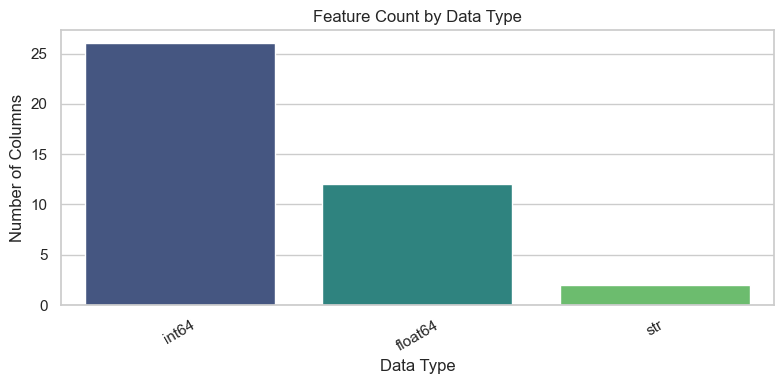

In [3]:
# Basic structure and summary stats
display(df.info())
display(df.describe(include="all").T)

# Missing values report
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_report = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
display(missing_report[missing_report["missing_count"] > 0])

# Duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

# Data types visualization
dtype_counts = df.dtypes.astype(str).value_counts()
plt.figure(figsize=(8, 4))
sns.barplot(x=dtype_counts.index, y=dtype_counts.values, palette="viridis")
plt.title("Feature Count by Data Type")
plt.xlabel("Data Type")
plt.ylabel("Number of Columns")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Key Observations (EDA-1)
- No missing Values
- No duplicate rows

## EDA-2: Outcome Variable Deep Dive

This section analyzes only the outcome variable for class distribution and imbalance.

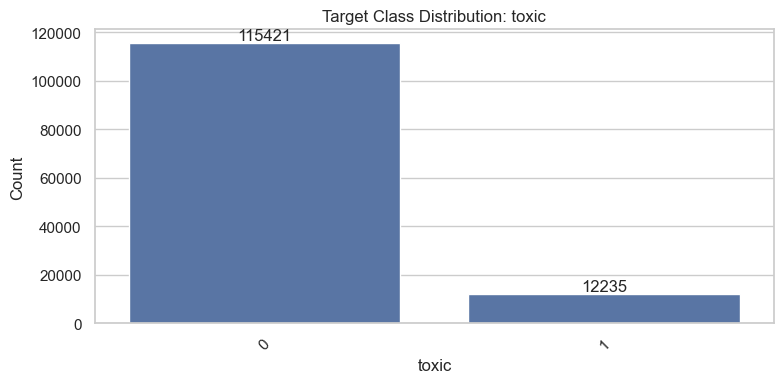

,count,pct
toxic,,
0,115421,90.42
1,12235,9.58


Imbalance ratio (majority/minority): 9.43


In [4]:
if TARGET_COLUMN not in df.columns:
    raise ValueError(
        f"TARGET_COLUMN='{TARGET_COLUMN}' not found. Update TARGET_COLUMN at top."
    )

plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df, x=TARGET_COLUMN, order=df[TARGET_COLUMN].value_counts().index)
plt.title(f"Target Class Distribution: {TARGET_COLUMN}")
plt.xlabel(TARGET_COLUMN)
plt.ylabel("Count")
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{int(h)}", (p.get_x() + p.get_width() / 2, h), ha="center", va="bottom")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

target_counts = df[TARGET_COLUMN].value_counts(dropna=False)
target_pct = df[TARGET_COLUMN].value_counts(normalize=True, dropna=False) * 100
display(pd.DataFrame({"count": target_counts, "pct": target_pct.round(2)}))

# Imbalance ratio (majority/minority) for classification
if len(target_counts) > 1:
    imbalance_ratio = target_counts.max() / target_counts.min()
    print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}")
else:
    print("Only one class detected in target.")

### Key Observations (EDA-2)

- Huge class imbalance toxic (1/0)
-stratification and/or class weighting  be needed later

## EDA-3: Train-Test Split Check (Leakage-Safe)

The split is already done. This section verifies representativeness and confirms leakage-safe setup before feature-level EDA on train only.

In [5]:
# Split representativeness checks (split already created upstream)
print(f"Train shape: {df.shape}")
print(f"Test shape:  {df_test.shape}")

if TARGET_COLUMN in df.columns and TARGET_COLUMN in df_test.columns:
    train_target_rate = df[TARGET_COLUMN].mean()
    test_target_rate = df_test[TARGET_COLUMN].mean()
    abs_gap = abs(train_target_rate - test_target_rate)

    print(f"Train {TARGET_COLUMN} rate: {train_target_rate:.4f}")
    print(f"Test  {TARGET_COLUMN} rate: {test_target_rate:.4f}")
    print(f"Absolute rate gap: {abs_gap:.4f}")

    split_report = pd.DataFrame(
        {
            "split": ["train", "test"],
            "rows": [len(df), len(df_test)],
            f"{TARGET_COLUMN}_rate": [train_target_rate, test_target_rate],
        }
    )
    display(split_report)
else:
    print(f"Target column '{TARGET_COLUMN}' missing in one of the splits.")

Train shape: (127656, 40)
Test shape:  (31915, 8)
Train toxic rate: 0.0958
Test  toxic rate: 0.0958
Absolute rate gap: 0.0000


,split,rows,toxic_rate
0,train,127656,0.095844
1,test,31915,0.095848


### Key Observations (EDA-3)

- Split is already provided and treated as fixed input.
- Train/test row counts are validated in the check cell.
- Target-rate gap between train and test is reported directly.
- Feature-level EDA remains train-only to stay leakage-safe.

## EDA-4: Feature-Level Deep Dive (Train Set Only)

This section analyzes engineered numeric features from `train_set_with_features.csv` and their relationship with the target.

Numeric feature columns analyzed: 32


,corr_with_toxic
vader_neg,0.482361
vader_pos_minus_neg,-0.360517
vader_compound,-0.298966
second_person_density,0.288947
vader_is_negative,0.280894
uppercase_ratio,0.230980
has_second_person,0.121583
vader_intensity,0.119888
identity_sexuality,0.100659
profanity_count,0.100494


toxic,non_toxic,toxic,toxic_minus_non_toxic
char_count,404.478024,294.712955,-109.765069
word_count,68.966115,51.064569,-17.901546
exclamation_count,0.357535,4.149571,3.792036
avg_sentence_length,12.848487,15.779480,2.930993
profanity_count,0.022370,2.399428,2.377058
second_person_count,1.675388,3.519166,1.843778
vader_compound,0.165222,-0.417191,-0.582412
vader_is_negative,0.286577,0.735104,0.448527
elongated_token_count,0.269197,0.653126,0.383929
negation_count,1.284680,0.927667,-0.357013


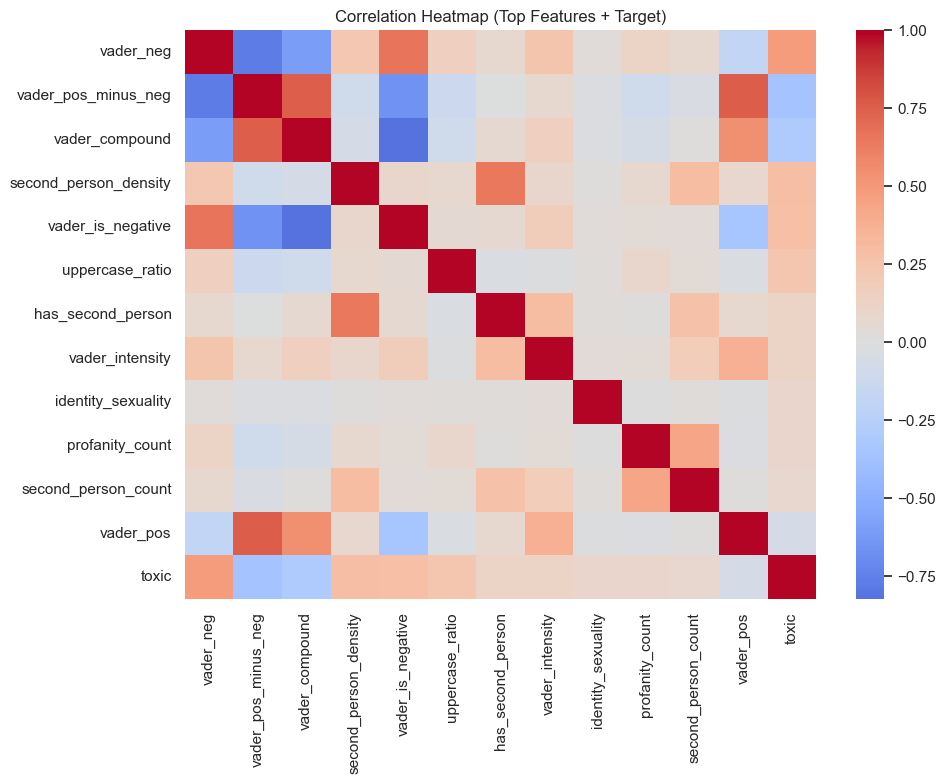

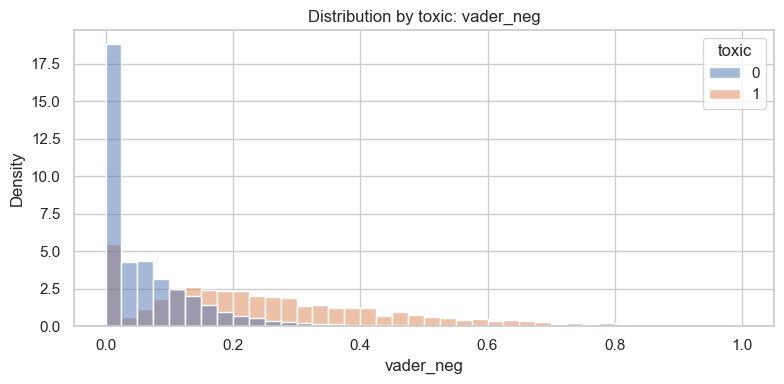

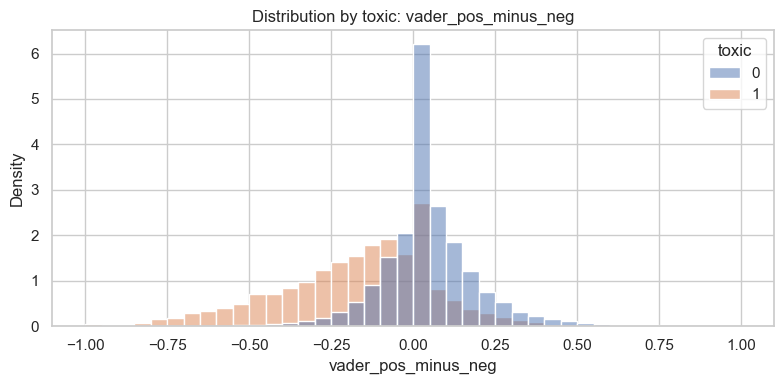

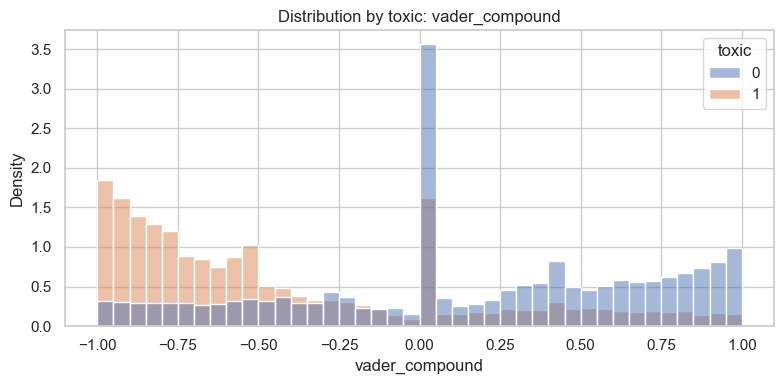

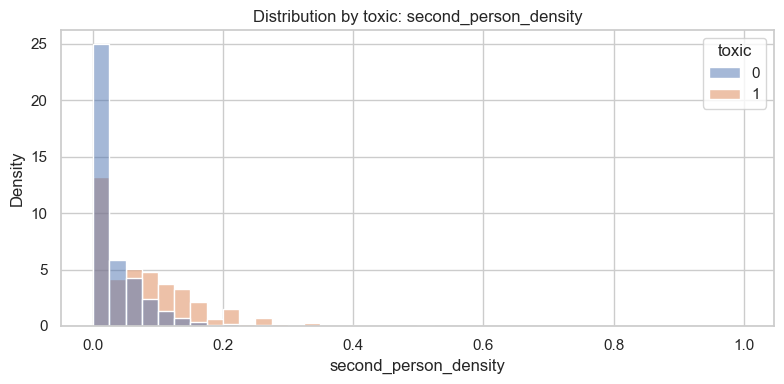

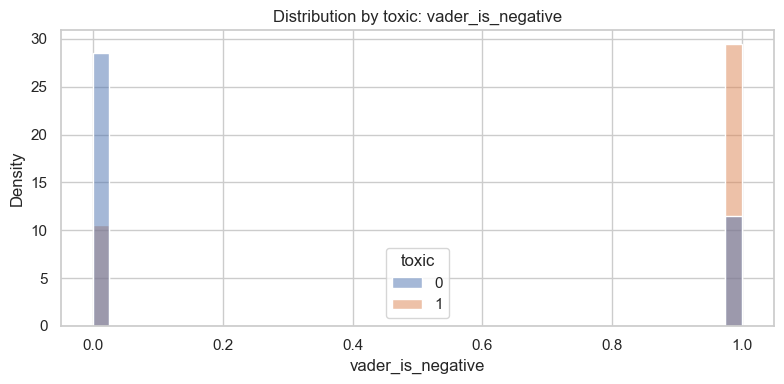

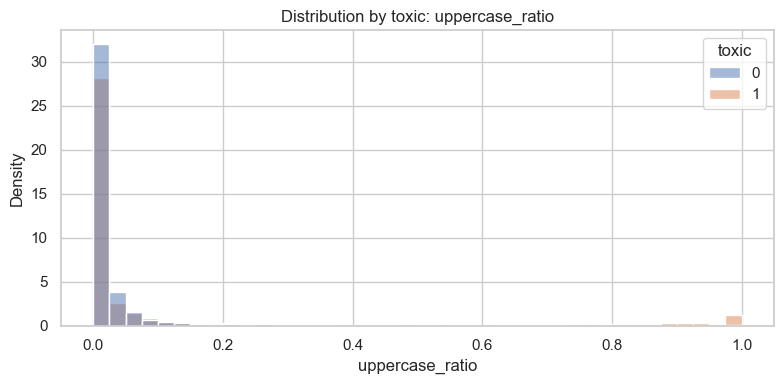

In [6]:
# Numeric-feature analysis on train split only
exclude_cols = {
    "id",
    "comment_text",
    TARGET_COLUMN,
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate",
}

numeric_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in exclude_cols
]

print(f"Numeric feature columns analyzed: {len(numeric_cols)}")

# Occurrence table: how often each feature is non-zero
occurrence_df = pd.DataFrame(index=numeric_cols)
occurrence_df["non_zero_count"] = (df[numeric_cols] != 0).sum(axis=0)
occurrence_df["non_zero_pct"] = (occurrence_df["non_zero_count"] / len(df) * 100).round(2)

if TARGET_COLUMN in df.columns:
    non_toxic_mask = df[TARGET_COLUMN] == 0
    toxic_mask = df[TARGET_COLUMN] == 1

    occurrence_df["non_zero_count_non_toxic"] = (df.loc[non_toxic_mask, numeric_cols] != 0).sum(axis=0)
    occurrence_df["non_zero_count_toxic"] = (df.loc[toxic_mask, numeric_cols] != 0).sum(axis=0)
    occurrence_df["non_zero_pct_non_toxic"] = (
        occurrence_df["non_zero_count_non_toxic"] / max(non_toxic_mask.sum(), 1) * 100
    ).round(2)
    occurrence_df["non_zero_pct_toxic"] = (
        occurrence_df["non_zero_count_toxic"] / max(toxic_mask.sum(), 1) * 100
    ).round(2)

occurrence_df = occurrence_df.sort_values("non_zero_count", ascending=False)
print("Feature occurrence (non-zero) in training data:")
display(occurrence_df)

# Correlation with target (absolute, strongest first)
feature_target_corr = (
    df[numeric_cols + [TARGET_COLUMN]]
    .corr(numeric_only=True)[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
display(feature_target_corr.to_frame(name=f"corr_with_{TARGET_COLUMN}").head(15))

# Compare feature means by target class
feature_means = (
    df.groupby(TARGET_COLUMN)[numeric_cols]
    .mean()
    .T
    .rename(columns={0: "non_toxic", 1: "toxic"})
)
feature_means["toxic_minus_non_toxic"] = feature_means["toxic"] - feature_means["non_toxic"]
feature_means = feature_means.sort_values(
    "toxic_minus_non_toxic", key=lambda s: s.abs(), ascending=False
)
display(feature_means.head(15))

# Correlation heatmap for top correlated features
top_corr_features = feature_target_corr.head(12).index.tolist()
if top_corr_features:
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        df[top_corr_features + [TARGET_COLUMN]].corr(numeric_only=True),
        cmap="coolwarm",
        center=0,
        annot=False,
    )
    plt.title("Correlation Heatmap (Top Features + Target)")
    plt.tight_layout()
    plt.show()

# Distribution plots for top 6 features
for col in top_corr_features[:6]:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, hue=TARGET_COLUMN, bins=40, stat="density", common_norm=False)
    plt.title(f"Distribution by {TARGET_COLUMN}: {col}")
    plt.tight_layout()
    plt.show()

### Key Observations (EDA-4)

- The strongest signal comes from sentiment negativity (`vader_neg`), while `vader_compound` and `vader_pos_minus_neg` decrease as toxicity increases.
- Direct-address features (`second_person_density`, `has_second_person`, `second_person_count`) are consistently higher for toxic comments.
- Style/intensity indicators (`uppercase_ratio`, `exclamation_count`) are higher in toxic texts and support class separation.
- `profanity_count` is clearly higher in toxic comments and provides useful predictive information.
- Length-based features (`char_count`, `word_count`) are weaker and slightly lower for toxic comments on average.
- Correlation heatmap suggests redundancy among some engineered features (especially sentiment-related), so multicollinearity should be monitored.

**Short recommendations**
- Use class weighting and threshold tuning due to class imbalance.
- Start with a regularized baseline model and compare against a tree-based model.
- Evaluate with F1 and PR-AUC, not accuracy alone.

## EDA-5: Modeling Readiness Checklist

- Train/test split remains fixed and leakage-safe.
- Train set includes engineered features ready for model training.
- Test set remains raw for later pipeline-based `transform()`.
- Target imbalance is confirmed and should be handled in modeling (e.g., class weights/threshold tuning).
- Candidate feature set for first baseline can be taken from top-ranked features in EDA-4.